# Lab 9

# Question: Can we set up partitions to identify currency types based on the variables of salary and the salary:USD salary ratio?

## Student Name: Cameron Mangione

## Imports + Dataset

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.datasets import get_rdataset
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from ISLP import load_data
from sklearn.cluster import \
     (KMeans,
      AgglomerativeClustering)
from scipy.cluster.hierarchy import \
     (dendrogram,
      cut_tree)
from ISLP.cluster import compute_linkage
from sklearn.metrics import silhouette_score

In [2]:
# Load the merged dataset
df = pd.read_csv("https://raw.githubusercontent.com/CameronMangione/Group_Project_2_DATA_5322/refs/heads/main/data/ds_merged_final.csv")
print("Dataset Preview:")
df.head()

Dataset Preview:


,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
0,2020,EX,FT,Staff Data Analyst,15000,USD,15000,NG,0,CA,M
1,2020,MI,FT,Business Data Analyst,95000,USD,95000,US,0,US,M
2,2020,EN,FT,Data Engineer,1000000,INR,13493,IN,100,IN,L
3,2020,EN,FT,Data Analyst,20000,EUR,22809,PT,100,PT,M
4,2020,EN,FT,Data Scientist,43200,EUR,49268,DE,0,DE,S


## Clearly state the question under your project topic and explain why this is interesting to analyze. Prepare an appropriate dataset for clustering. List and explain the variables included in the clustering analysis. If variables are measured on different scales, standardize the variables. 

Based on our question above, this question is worth analyzing because we want to look at how well k-means clustering can be in identifying currency types based on salary and a salary ratio alone. It's interesting to analyze this question because it additionally helps us develop a better understanding of data science salaries in different countries.

In terms of preparing our dataset, we start with creating a clean copy of the data to preserve our initial dataset.
From there, we narrow down our features to salary, salary in usd, and salary currency.
Lastly, we create a derived column for our 'salary ratio' of salary divided by US salary so we can conduct our k-means cluster.

In [3]:
clean = df.copy()

In [4]:
clean = clean[['salary','salary_in_usd','salary_currency']]

In [5]:
clean['salary_ratio'] = clean['salary'] / clean['salary_in_usd']

After our initial cleaning, we filter our dataset for for three currencies: The Euro, the Canadian Dollar, and the British Pound. These currencies were ones that we wanted to look at specifically since we know that US currency would be 1 for all of our ratios.

In [6]:
clean_2 = clean.loc[(clean['salary_currency'] == 'EUR') | (clean['salary_currency'] == 'CAD') | (clean['salary_currency'] == 'GBP')]
clean_2.reset_index()

,index,salary,salary_in_usd,salary_currency,salary_ratio
0,3,20000,22809,EUR,0.876847
1,4,43200,49268,EUR,0.876837
2,5,157000,117104,CAD,1.340689
3,6,48000,54742,EUR,0.876840
4,8,51999,59303,EUR,0.876836
...,...,...,...,...,...
429,2626,35000,37558,EUR,0.931892
430,2654,62000,75344,GBP,0.822892
431,2655,52000,63192,GBP,0.822889
432,2658,48000,58331,GBP,0.822890


A first impression of our filtered dataset shows that EUR and GBP have similar ratios but CAD is closer to 1.3, indicating that it is weaker than the US dollar.
We take a preliminary look at our value counts for each currency, noting that we have more data on euro and pound observations than canadian dollar observations, but this should not impact our data too much.
We also remove salary_in_usd to get our final dataset that we will use to create our scaled dataset and run our clusters.

In [7]:
clean_2.head(20)

,salary,salary_in_usd,salary_currency,salary_ratio
3,20000,22809,EUR,0.876847
4,43200,49268,EUR,0.876837
5,157000,117104,CAD,1.340689
6,48000,54742,EUR,0.876840
8,51999,59303,EUR,0.876836
10,60000,68428,EUR,0.876834
12,41000,46759,EUR,0.876837
13,65000,74130,EUR,0.876838
19,70000,79833,EUR,0.876830
20,44000,50180,EUR,0.876843


In [8]:
clean_2['salary_currency'].value_counts()

salary_currency
EUR    229
GBP    173
CAD     32
Name: count, dtype: int64

In [9]:
clean_3 = clean_2[['salary','salary_ratio']]
clean_3.shape

(434, 2)

We scale our data, and set up our k-means cluster. Note that we start with three clusters because we know in advance what our groups should be before heading into our clusters. We still don't know exactly how this will turn out but it is something that we will note here since we already modified this dataset a bit before running this model.

In [10]:
scaler = StandardScaler()
ds_scaled = scaler.fit_transform(clean_3)
kmeans = KMeans(n_clusters=3,
                random_state=2,
                n_init=20).fit(ds_scaled)
kmeans = KMeans(n_clusters=3,
                random_state=2,
                n_init=20).fit(ds_scaled)

\\?\C:\Users\2TBSSD\AppData\Roaming\jupyterlab-desktop\envs\env_2\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
\\?\C:\Users\2TBSSD\AppData\Roaming\jupyterlab-desktop\envs\env_2\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


## Part 2. Run K-means clustering using several possible values of K and justify your choices. Examine the clustering result using the elbow method or silhouette scores and discuss whether the number of groups is meaningful under the data and question context.

We set up our labels method to verify that it alighs with the model that we were looking to set up, and we can verify that it is successfully set up the way we wanted.

In [11]:
kmeans.labels_

array([0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0,
       0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 2, 2, 2,
       0, 1, 0, 0, 0, 0, 0, 1, 1, 1, 1, 2, 0, 1, 0, 1, 0, 0, 2, 2, 2, 0,
       0, 0, 0, 0, 0, 1, 2, 0, 2, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0,
       2, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 0, 0, 1, 0, 1,
       0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 2,
       1, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0,
       0, 0, 1, 1, 0, 2, 0, 1, 1, 2, 0, 0, 2, 0, 0, 1, 1, 0, 0, 1, 0, 0,
       0, 0, 1, 0, 1, 1, 1, 0, 1, 0, 1, 0, 0, 1, 1, 0, 0, 1, 1, 1, 1, 0,
       0, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 1, 1, 1, 0,
       2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0,
       0, 0, 1, 1, 2, 2, 0, 0, 2, 0, 2, 2, 0, 0, 1, 2, 0, 0, 0, 0, 1, 1,
       0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 1, 1, 1, 1, 1, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 1, 0,

Our graph here shows some intriguing results. First, without us previously knowing we were working with three currencies, the distribution more looks like two clusters rather than three distinct clusters.
The large gap between the two clusters accounts for the difference between CAD and EUR + GBP.
We see one major outlier in the yellow cluster around (7,-0.5).

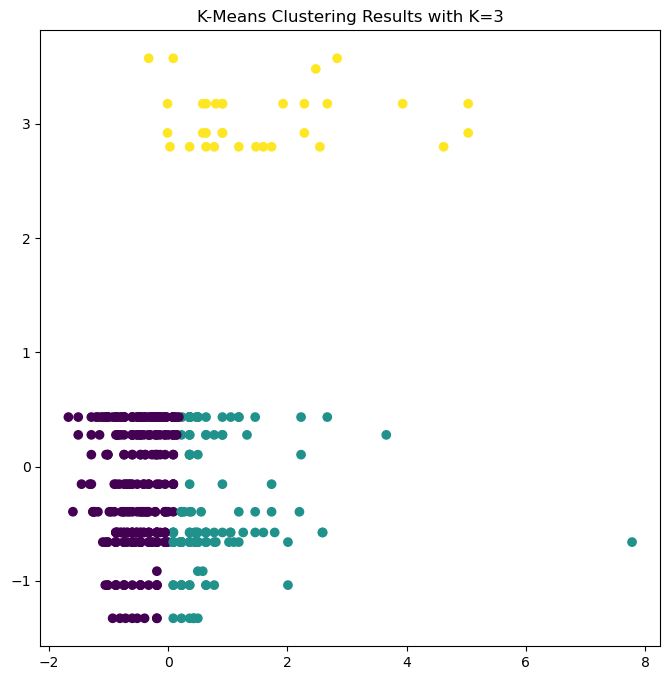

In [12]:
fig, ax = plt.subplots(figsize=(8,8))
ax.scatter(ds_scaled[:,0], ds_scaled[:,1], c=kmeans.labels_)
ax.set_title("K-Means Clustering Results with K=3");

Although we were able to establish a reasonable k-means clustering using some prior knowledge and modification of our original dataset, we can also use some validation methods to trest inertia and silhouette scores at different k values.

In [13]:
from sklearn.metrics import silhouette_score

# Compare several possible values of K
K_elbow = range(1, 11)
K_silhouette = range(2, 11)

inertias = []
silhouette_scores = []

# Inertia can be computed for K = 1, 2, ..., 10
for k in K_elbow:
    kmeans = KMeans(n_clusters=k,
                    random_state=2,
                    n_init=20).fit(ds_scaled)
    inertias.append(kmeans.inertia_)

# Silhouette score is only defined when there are at least two clusters
for k in K_silhouette:
    kmeans = KMeans(n_clusters=k,
                    random_state=2,
                    n_init=20).fit(ds_scaled)
    silhouette_scores.append(silhouette_score(ds_scaled, kmeans.labels_))

k_summary = pd.DataFrame({
    'K': list(K_elbow),
    'Inertia': inertias,
    'Silhouette Score': [np.nan] + silhouette_scores
})

k_summary

\\?\C:\Users\2TBSSD\AppData\Roaming\jupyterlab-desktop\envs\env_2\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
\\?\C:\Users\2TBSSD\AppData\Roaming\jupyterlab-desktop\envs\env_2\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
\\?\C:\Users\2TBSSD\AppData\Roaming\jupyterlab-desktop\envs\env_2\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
\\?\C:\Users\

,K,Inertia,Silhouette Score
0,1,868.000000,NaN
1,2,443.294386,0.703838
2,3,318.433461,0.400850
3,4,239.686407,0.399052
4,5,177.338228,0.411158
5,6,142.641467,0.420616
6,7,113.483962,0.439885
7,8,91.502436,0.434257
8,9,77.169430,0.440777
9,10,66.862684,0.432361


Our results show that K = 3 seems to show a reasonalbe  K value since we see a major drop off from 2 to 3 and then a reasonable plateau around 38-40% after that point. This also makes sense for us since we had three groups here and having too many groups would not make sense to interpret in this context.

We can also plot the results of our elbow method and silhouette scores that reflect our findings.

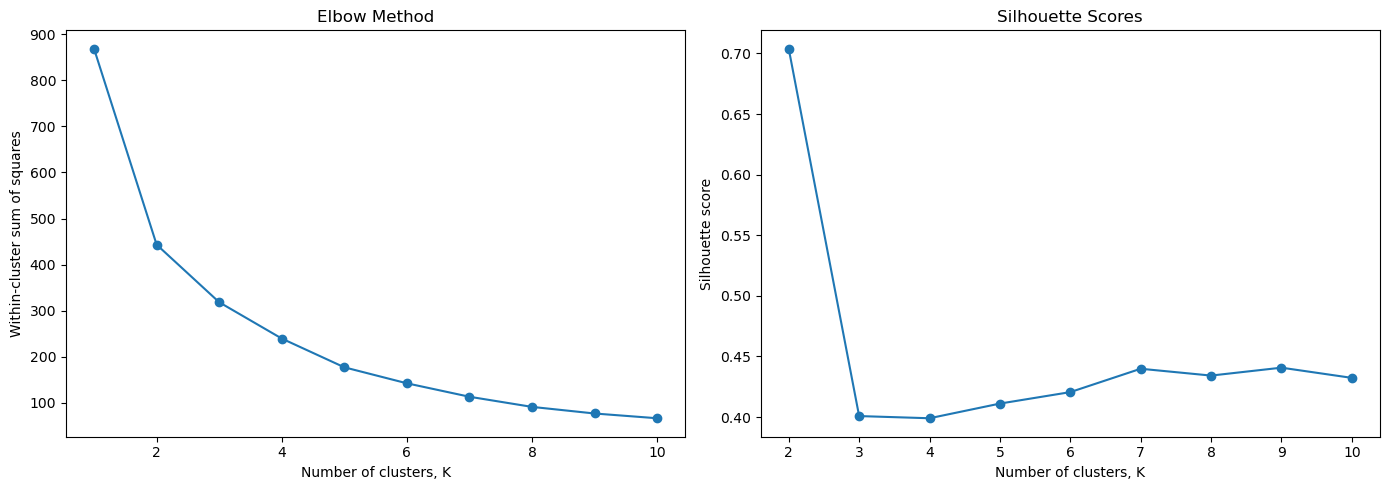

In [14]:
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Elbow plot
ax[0].plot(list(K_elbow), inertias, marker='o')
ax[0].set_xlabel("Number of clusters, K")
ax[0].set_ylabel("Within-cluster sum of squares")
ax[0].set_title("Elbow Method")

# Silhouette plot
ax[1].plot(list(K_silhouette), silhouette_scores, marker='o')
ax[1].set_xlabel("Number of clusters, K")
ax[1].set_ylabel("Silhouette score")
ax[1].set_title("Silhouette Scores")

plt.tight_layout();

## Part 3. Apply hierarchical clustering to the same standardized dataset from Part 2. Use at least two different linkage methods. Create dendrograms for the hierarchical clustering results. Interpret the dendrogram and choose a reasonable number of clusters based on your project context.

We first set up our hierarchical clustering function and define a function that will plot three different linkage methods (complete, average, single) and dendrograms for each.

In [15]:
HClust = AgglomerativeClustering

In [16]:
def plot_nci(linkage, ax, cut=-np.inf):
    cargs = {'above_threshold_color':'black',
             'color_threshold':cut}
    hc = HClust(n_clusters=None,
                distance_threshold=0,
                linkage=linkage.lower()).fit(ds_scaled)
    linkage_ = compute_linkage(hc)
    dendrogram(linkage_,
               ax=ax,
               labels=np.asarray(clean_2['salary_currency']),
               leaf_font_size=10,
               **cargs)
    ax.set_title('%s Linkage' % linkage)
    return hc

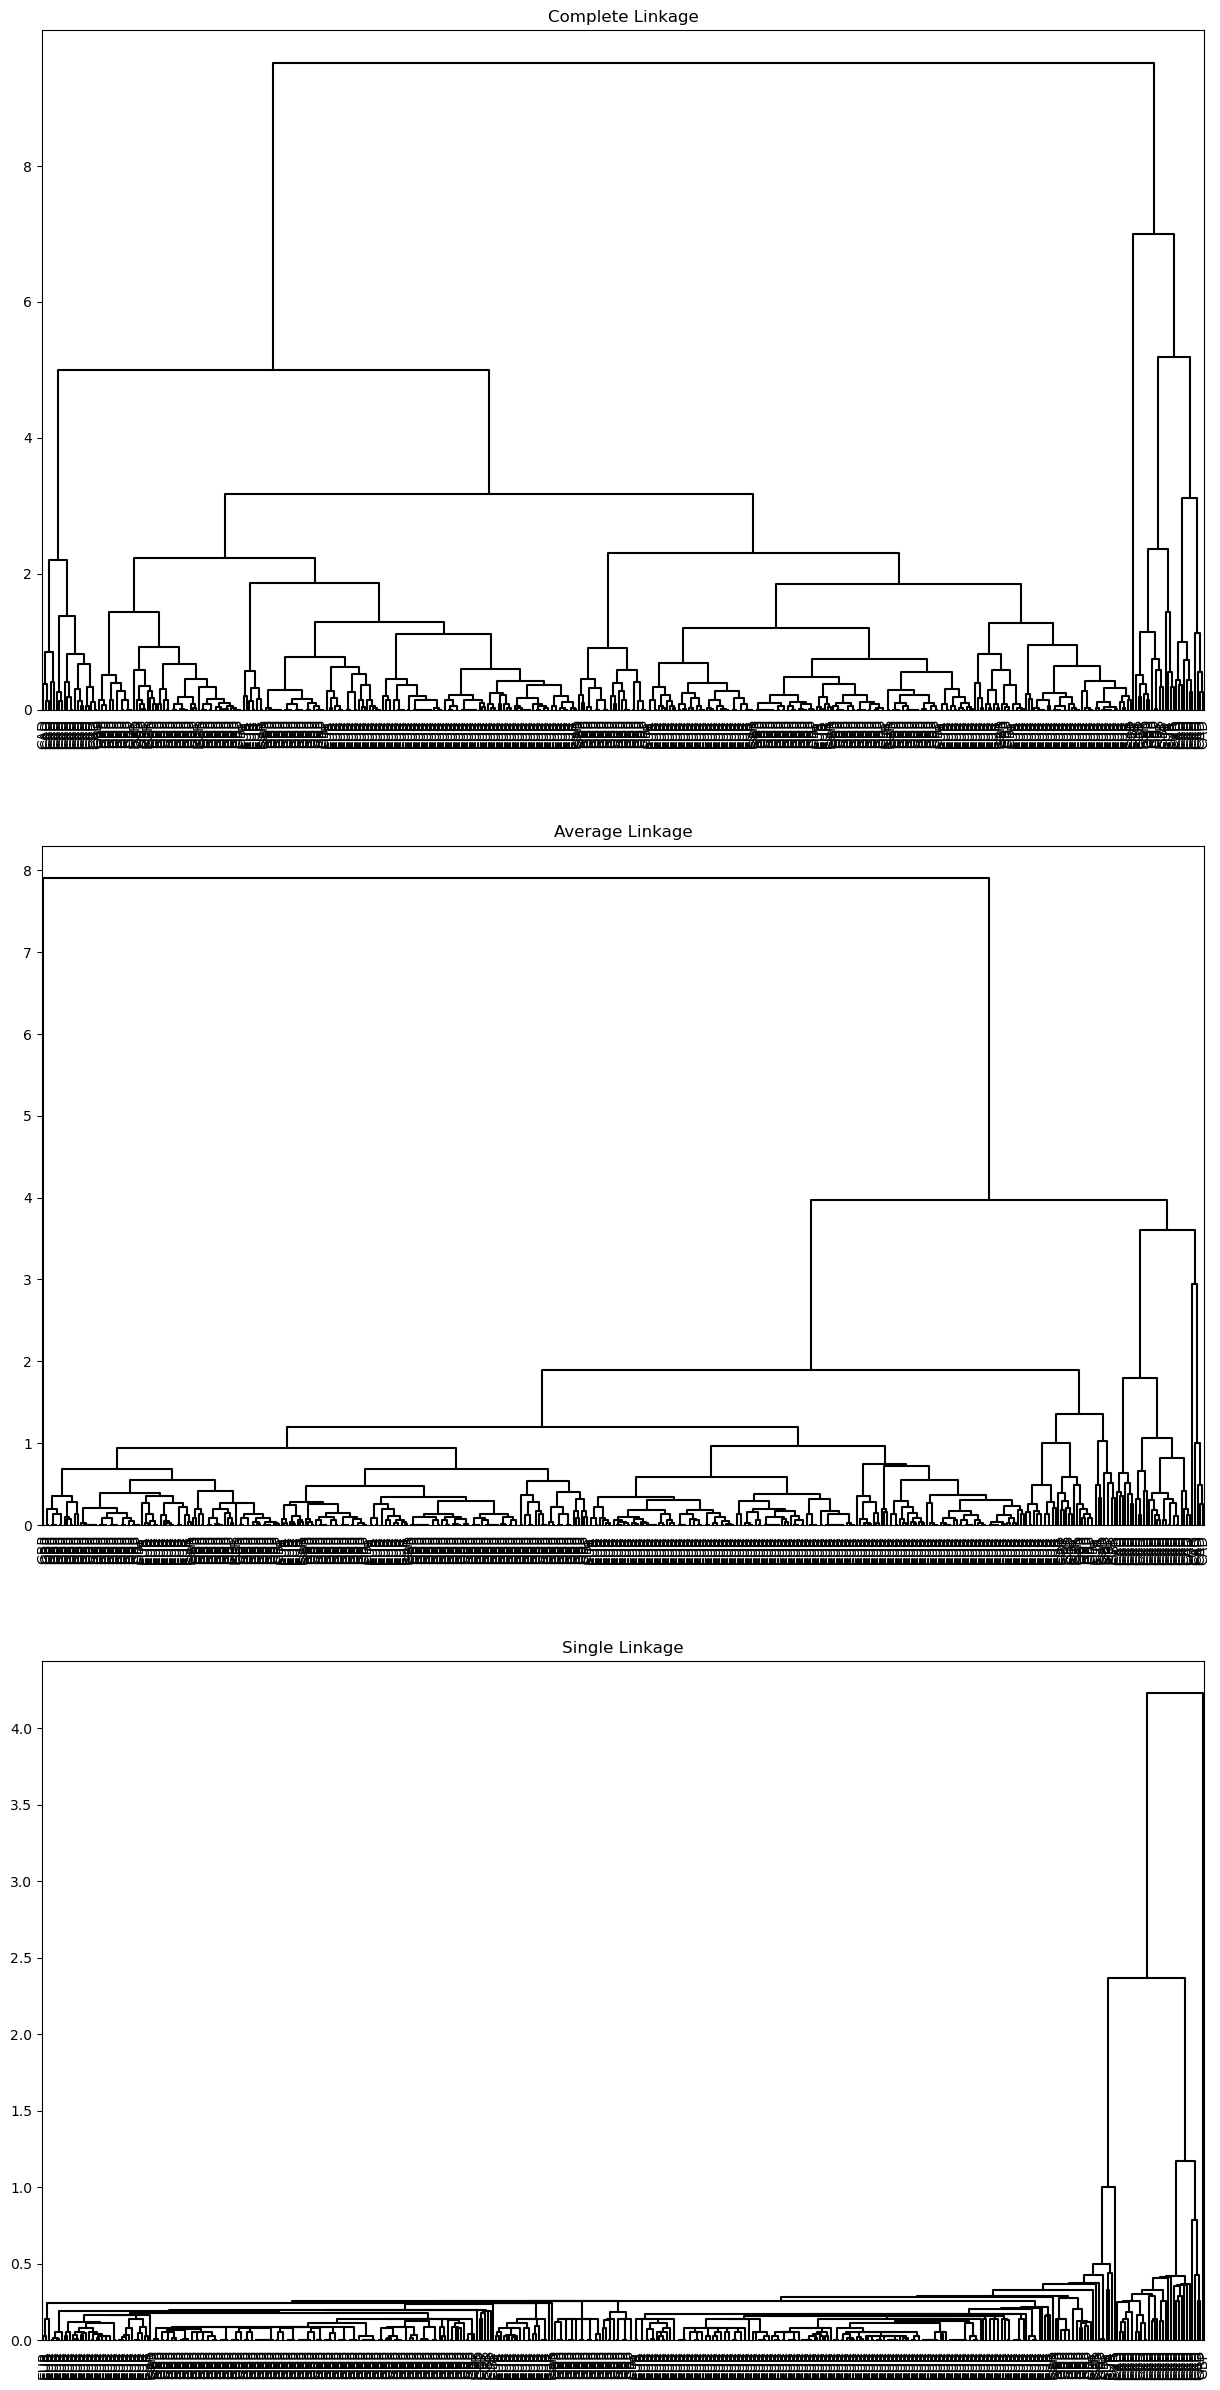

In [17]:
fig, axes = plt.subplots(3, 1, figsize=(15,30))
ax = axes[0]; hc_comp = plot_nci('Complete', ax)
ax = axes[1]; hc_avg = plot_nci('Average', ax)
ax = axes[2]; hc_sing = plot_nci('Single', ax)

These dendrograms are fairly difficult to interepret due to the fact that we have526 observations. It is worth noting that the single linkage has a heavy left skew that does not appear as aggressively in the completet and average linkages.

For our final model, we chose 4 clusters since that produces three different groups here (0,1,2), and cutting aorund five gives us three different groups as well.

In [18]:
linkage_comp = compute_linkage(hc_comp)
comp_cut = cut_tree(linkage_comp, n_clusters=4).reshape(-1)
pd.crosstab(clean_2['salary_currency'],
            pd.Series(comp_cut.reshape(-1), name='Complete'))

Complete,0,1,2
salary_currency,,,
CAD,11,0,0
EUR,76,1,2
GBP,19,0,0


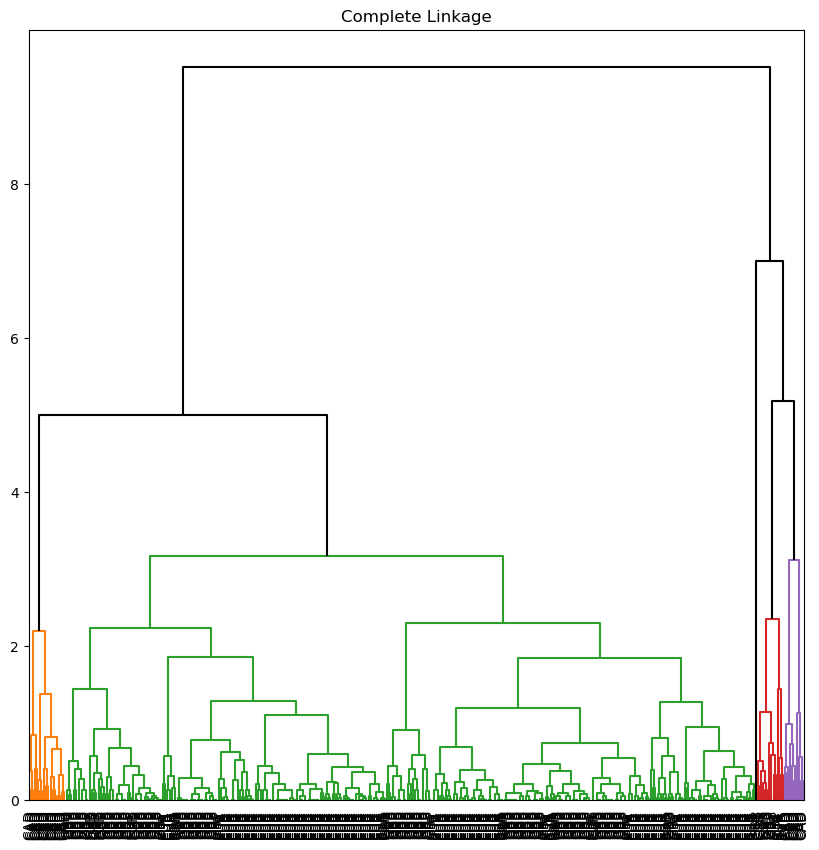

In [19]:
fig, ax = plt.subplots(figsize=(10,10))
plot_nci('Complete', ax, cut=5)
ax.axhline(140, c='r', linewidth=4);